<a href="https://colab.research.google.com/github/AshokGit544/Multivariate-Gaussian-Anomaly-Detection/blob/main/Multivariate_Gaussian_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estimated Mean:
[ 69.46334958 230.26184508  15.03979377]

Estimated Covariance Matrix:
[[16.16111984  2.99103874  2.34438733]
 [ 2.99103874 14.0861137   2.28373336]
 [ 2.34438733  2.28373336  5.09311498]]

Sample Output:
     Temperature     Voltage    Current   Probability  Anomaly
194    71.520561  221.713838  14.668674  9.024560e-05    False
195    68.417687  230.916024  13.064432  1.254430e-03    False
196    65.033271  230.391146  14.428236  1.065531e-03    False
197    72.714387  229.726822  16.093470  1.309792e-03    False
198    64.930628  228.934808  13.523672  9.909500e-04    False
199    73.051141  233.684400  16.691857  9.630704e-04    False
200    95.000000  210.000000   8.000000  8.573717e-25     True
201   100.000000  250.000000   5.000000  4.191732e-32     True
202    50.000000  260.000000  30.000000  8.679387e-35     True
203   110.000000  220.000000   6.000000  4.303010e-38     True


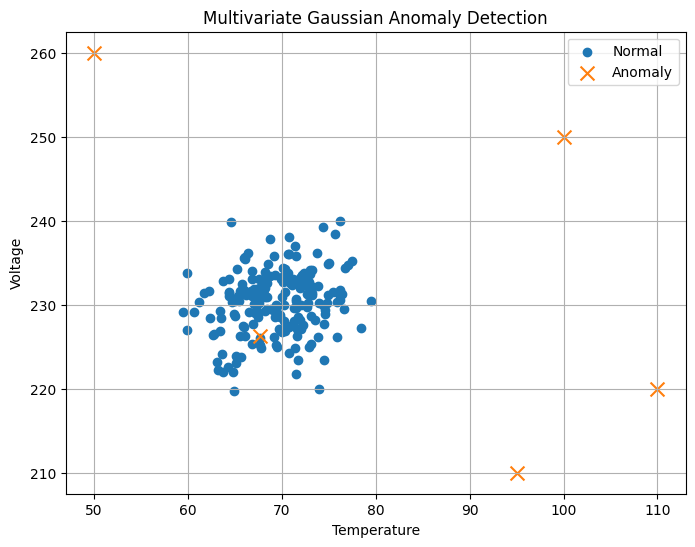

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Step 1: Create normal transformer sensor data
mean = [70, 230, 15]  # temperature, voltage, current
cov = [
    [20, 5, 3],
    [5, 15, 2],
    [3, 2, 5]
]

normal_data = np.random.multivariate_normal(mean, cov, 200)

# Step 2: Create a few abnormal readings
anomalies = np.array([
    [95, 210, 8],
    [100, 250, 5],
    [50, 260, 30],
    [110, 220, 6]
])

# Combine into one dataset
all_data = np.vstack([normal_data, anomalies])

df = pd.DataFrame(all_data, columns=["Temperature", "Voltage", "Current"])

# Step 3: Estimate mean and covariance from data
mu = np.mean(normal_data, axis=0)
sigma = np.cov(normal_data, rowvar=False)

# Step 4: Multivariate Gaussian probability function
def multivariate_gaussian(x, mu, sigma):
    n = len(mu)
    sigma_det = np.linalg.det(sigma)
    sigma_inv = np.linalg.inv(sigma)
    diff = x - mu
    exponent = -0.5 * np.sum(diff @ sigma_inv * diff, axis=1)
    coeff = 1 / np.sqrt(((2 * np.pi) ** n) * sigma_det)
    return coeff * np.exp(exponent)

# Step 5: Compute probabilities
probs = multivariate_gaussian(all_data, mu, sigma)

df["Probability"] = probs

# Step 6: Set threshold for anomaly detection
threshold = np.percentile(probs, 2)

df["Anomaly"] = df["Probability"] < threshold

print("Estimated Mean:")
print(mu)

print("\nEstimated Covariance Matrix:")
print(sigma)

print("\nSample Output:")
print(df.tail(10))

# Step 7: Plot Temperature vs Voltage
plt.figure(figsize=(8, 6))
normal_points = df[df["Anomaly"] == False]
anomaly_points = df[df["Anomaly"] == True]

plt.scatter(normal_points["Temperature"], normal_points["Voltage"], label="Normal")
plt.scatter(anomaly_points["Temperature"], anomaly_points["Voltage"], marker="x", s=100, label="Anomaly")

plt.xlabel("Temperature")
plt.ylabel("Voltage")
plt.title("Multivariate Gaussian Anomaly Detection")
plt.legend()
plt.grid(True)
plt.show()